ใช้ข้อมูลจากชุดข้อมูล SMS Spam Collection Dataset ซึ่งเผยแพร่ผ่าน Kaggle

(https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
)

โดยใช้ไฟล์ข้อมูลต้นฉบับชื่อ spam.csv และได้ทำการปรับสมดุลข้อมูล (balancing)

เพื่อให้จำนวนข้อมูลประเภท ham และ spam เท่ากัน
ซึ่งได้ไฟล์ใหม่ชื่อ spam_balanced.csv

นำเข้าไลบรารีและโหลดข้อมูล

In [1]:
# นำเข้าไลบรารีพื้นฐานสำหรับการจัดการข้อมูล
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# ดาวน์โหลดชุดคำฟุ่มเฟือย (Stopwords)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# โหลดข้อมูลจากไฟล์ spam.csv
df = pd.read_csv('spam_balanced.csv', encoding='latin-1')

# ดูหน้าตาข้อมูลเบื้องต้น
print("ข้อมูลก่อนทำความสะอาด:")
print(df.head())



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


ข้อมูลก่อนทำความสะอาด:
    v1                                                 v2
0  ham  Come to mu, we're sorting out our narcotics si...
1  ham  We can go 4 e normal pilates after our intro...  
2  ham            Have you laid your airtel line to rest?
3  ham                   Gokila is talking with you aha:)
4  ham                    We confirm eating at esplanade?


ทำความสะอาดคอลัมน์

In [2]:
# ลบคอลัมน์ที่ไม่มีข้อมูล (v2, v3, v4) ทิ้งไป
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, errors='ignore')

# เปลี่ยนชื่อคอลัมน์ให้เข้าใจง่ายขึ้น (v1 -> label, v2 -> message)
df.columns = ['label', 'message']

print("\nข้อมูลหลังจัดการคอลัมน์:")
print(df.head())


ข้อมูลหลังจัดการคอลัมน์:
  label                                            message
0   ham  Come to mu, we're sorting out our narcotics si...
1   ham  We can go 4 e normal pilates after our intro...  
2   ham            Have you laid your airtel line to rest?
3   ham                   Gokila is talking with you aha:)
4   ham                    We confirm eating at esplanade?


ดูจำนวนข้อความทั้งหมด

In [3]:
print("ขนาดของข้อมูล (แถว, คอลัมน์):", df.shape)

ขนาดของข้อมูล (แถว, คอลัมน์): (1494, 2)


ตรวจสอบว่ามีข้อมูลสูญหาย (Missing values) หรือไม่

In [4]:
print("\nจำนวนข้อมูลที่สูญหายในแต่ละคอลัมน์:\n", df.isnull().sum())


จำนวนข้อมูลที่สูญหายในแต่ละคอลัมน์:
 label      0
message    0
dtype: int64


ดูสัดส่วน Ham vs Spam

In [5]:
# ดูสัดส่วนระหว่างคลาส Ham (ข้อความปกติ) และ Spam
print("\nจำนวนข้อความในแต่ละคลาส:")
print(df['label'].value_counts())



จำนวนข้อความในแต่ละคลาส:
label
ham     747
spam    747
Name: count, dtype: int64


/tmp/ipykernel_553/1281323604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


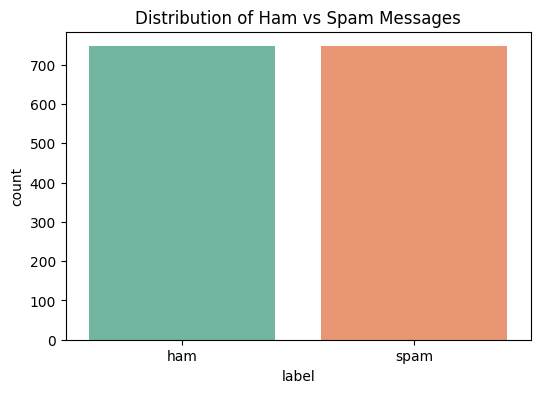

In [6]:
# พล็อตกราฟแท่งเพื่อดูสัดส่วน
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Distribution of Ham vs Spam Messages')
plt.show()

วิเคราะห์ความยาวข้อความ

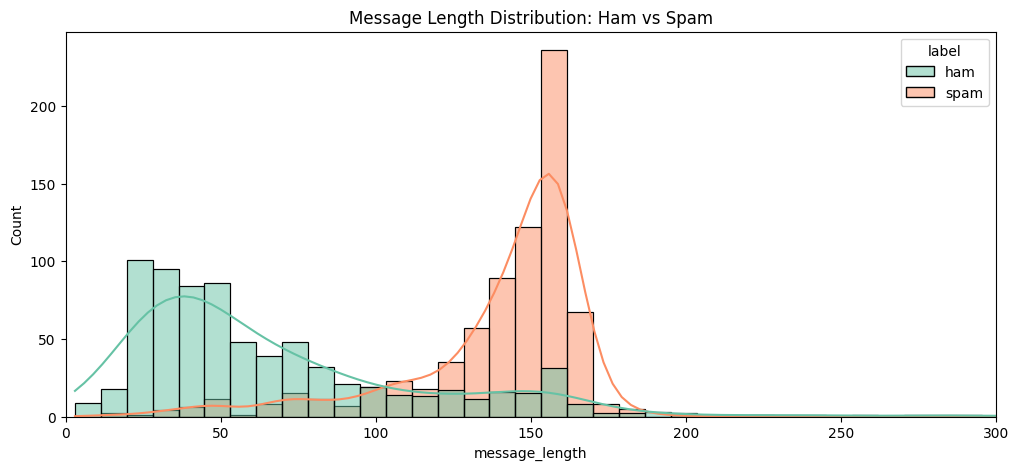

In [7]:
# สร้างคอลัมน์ใหม่เพื่อดู "ความยาวของข้อความ"
df['message_length'] = df['message'].apply(len)

# พล็อตกราฟดูการกระจายตัวของความยาวข้อความ
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=70, kde=True, palette='Set2')
plt.title('Message Length Distribution: Ham vs Spam')
plt.xlim(0, 300) # จำกัดแกน x ไม่ให้ยาวเกินไป
plt.show()

ทำความสะอาดข้อความและแปลงเป็น Vector

In [8]:
# ฟังก์ชันทำความสะอาดข้อความ
def clean_text(text):
    text = text.lower() # แปลงเป็นตัวพิมพ์เล็ก
    text = re.sub(r'[^a-z\s]', '', text) # ลบตัวเลข เครื่องหมายวรรคตอน เก็บแค่ a-z
    # ตัดคำและลบ Stopwords (เช่น is, am, the)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words) # ประกอบคำกลับเป็นประโยค

# ประยุกต์ใช้ฟังก์ชันทำความสะอาดกับคอลัมน์ message
df['cleaned_message'] = df['message'].apply(clean_text)

# แปลง Label จากข้อความให้เป็นตัวเลข (Ham = 0, Spam = 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# แปลงข้อความเป็นตัวเลข (Vector) ด้วยวิธี TF-IDF
# max_features=3000 คือเลือกเฉพาะคำที่พบบ่อย 3000 คำแรก เพื่อลดขนาดข้อมูล
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['cleaned_message']).toarray() # ตัวแปรต้น (Features)
y = df['label_num'].values # ตัวแปรตาม (Target)

print(f"แปลงข้อความเป็นตัวเลขเรียบร้อย! ขนาดของข้อมูลคือ: {X.shape}")

แปลงข้อความเป็นตัวเลขเรียบร้อย! ขนาดของข้อมูลคือ: (1494, 3000)


แบ่งข้อมูล Train/Test

In [9]:
from sklearn.model_selection import train_test_split

# แบ่งข้อมูล X และ y
# test_size=0.2 คือแบ่งไป Test 20%
# random_state=42 เพื่อล็อกผลการสุ่มให้เหมือนเดิมทุกครั้งที่รันโค้ด
# stratify=y เพื่อให้สัดส่วนของ Spam/Ham ในชุด Train และ Test เท่าๆ กัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"จำนวนข้อมูลสำหรับเทรน (Train): {X_train.shape[0]} ตัวอย่าง")
print(f"จำนวนข้อมูลสำหรับทดสอบ (Test): {X_test.shape[0]} ตัวอย่าง")

จำนวนข้อมูลสำหรับเทรน (Train): 1195 ตัวอย่าง
จำนวนข้อมูลสำหรับทดสอบ (Test): 299 ตัวอย่าง


สร้างและฝึกสอน Naive Bayes

In [10]:
from sklearn.naive_bayes import MultinomialNB

# สร้างตัวแบบ (Model)
model = MultinomialNB()

# สั่งให้โมเดลเรียนรู้ (Train) จากชุดข้อมูล X_train และ y_train
model.fit(X_train, y_train)

# ให้โมเดลทำนายผลลัพธ์จากชุดข้อมูลทดสอบ X_test ที่มันไม่เคยเห็นมาก่อน
y_pred = model.predict(X_test)

print("ฝึกสอนโมเดลและทำการทำนายผลสำเร็จ!")

ฝึกสอนโมเดลและทำการทำนายผลสำเร็จ!


ประเมินผล Naive Bayes

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# คำนวณความแม่นยำรวม (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"ความแม่นยำของโมเดล (Accuracy): {accuracy * 100:.2f}%\n")

# ดูรายงานเชิงลึก (Precision, Recall, F1-Score)
print("--- รายงานการจำแนกประเภท (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))



ความแม่นยำของโมเดล (Accuracy): 94.98%

--- รายงานการจำแนกประเภท (Classification Report) ---
              precision    recall  f1-score   support

     Ham (0)       0.94      0.96      0.95       150
    Spam (1)       0.96      0.94      0.95       149

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



 Confusion Matrix

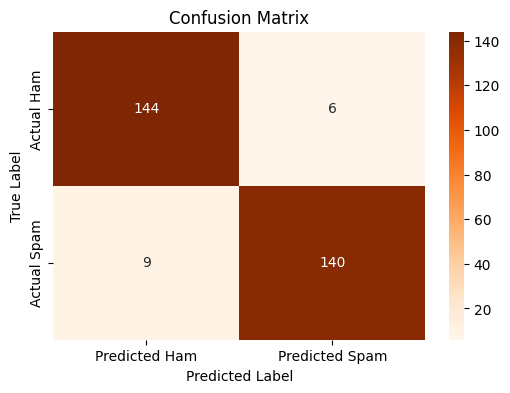

In [12]:
# วาดกราฟ Confusion Matrix เพื่อดูการทายถูก/ผิด ในแต่ละประเภท
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

ทดสอบ Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. Logistic Regression Model
# ==========================================
print("=== ผลลัพธ์จากโมเดล Logistic Regression ===")
# สร้างและฝึกสอนโมเดล
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

# ทำนายและประเมินผล
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"ความแม่นยำ (Accuracy): {acc_log * 100:.2f}%")
print(classification_report(y_test, y_pred_log, target_names=['Ham (0)', 'Spam (1)']))
print("-" * 50, "\n")

=== ผลลัพธ์จากโมเดล Logistic Regression ===
ความแม่นยำ (Accuracy): 92.31%
              precision    recall  f1-score   support

     Ham (0)       0.88      0.98      0.93       150
    Spam (1)       0.98      0.87      0.92       149

    accuracy                           0.92       299
   macro avg       0.93      0.92      0.92       299
weighted avg       0.93      0.92      0.92       299

-------------------------------------------------- 



ทดสอบ SVM

In [14]:
# ==========================================
# 2. Support Vector Machine (SVM) Model
# ==========================================
print("=== ผลลัพธ์จากโมเดล Support Vector Machine (SVM) ===")
# สร้างและฝึกสอนโมเดล (ใช้ kernel='linear' มักจะทำงานได้ดีกับข้อมูลข้อความ Text)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# ทำนายและประเมินผล
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"ความแม่นยำ (Accuracy): {acc_svm * 100:.2f}%")
print(classification_report(y_test, y_pred_svm, target_names=['Ham (0)', 'Spam (1)']))
print("-" * 50, "\n")

=== ผลลัพธ์จากโมเดล Support Vector Machine (SVM) ===
ความแม่นยำ (Accuracy): 93.31%
              precision    recall  f1-score   support

     Ham (0)       0.89      0.99      0.94       150
    Spam (1)       0.98      0.88      0.93       149

    accuracy                           0.93       299
   macro avg       0.94      0.93      0.93       299
weighted avg       0.94      0.93      0.93       299

-------------------------------------------------- 



สรุปเปรียบเทียบโมเดล

In [15]:
# ==========================================
# 3. เปรียบเทียบประสิทธิภาพทั้ง 3 โมเดล
# ==========================================
# ดึงค่า accuracy ของ Naive Bayes จากตัวแปรเดิม (ถ้าคุณรัน cell ก่อนหน้ามาแล้ว)
acc_nb = accuracy_score(y_test, model.predict(X_test))

print("=== 🏆 สรุปเปรียบเทียบความแม่นยำ (Accuracy) ===")
print(f"1. Naive Bayes:        {acc_nb * 100:.2f}%")
print(f"2. Logistic Regression: {acc_log * 100:.2f}%")
print(f"3. SVM (Linear):       {acc_svm * 100:.2f}%")

=== 🏆 สรุปเปรียบเทียบความแม่นยำ (Accuracy) ===
1. Naive Bayes:        94.98%
2. Logistic Regression: 92.31%
3. SVM (Linear):       93.31%


Naive Bayes ให้ผลดีที่สุดสำหรับ Dataset นี้ เนื่องจากสามารถหาเส้นแบ่ง (Hyperplane) ที่เหมาะสมในมิติสูง